<a href="https://colab.research.google.com/github/nesbita/ML-Collision-Severity-YOLO-Detection/blob/main/Ariana_Nesbit_Ass2_T21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U ultralytics
from ultralytics import YOLO
model = YOLO('yolo11n.pt')
print('YOLO installed successfully')
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

YOLO installed successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/kitti3k_yolo'
CAR_ONLY_PATH = '/content/drive/MyDrive/kitti3k_car_only'

import os
import shutil


shutil.copytree(DATASET_PATH, '/content/kitti3k_yolo')
print('Dataset copied to local storage.')
print(os.listdir('/content/kitti3k_yolo'))

print(os.listdir('/content/'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset copied to local storage.
['images', 'kitti3k.yaml', 'labels']
['.config', 'drive', 'yolo11n.pt', 'kitti3k_yolo', 'sample_data']


Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2660.6±1684.8 MB/s, size: 799.6 KB)
val: Scanning /content/kitti3k_yolo/labels/test... 450 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 450/450 503.3it/s 0.9s
val: New cache created: /content/kitti3k_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 3.3it/s 8.8s
                   all        450       1795      0.784      0.625      0.713      0.405
                   car        394       1795      0.784      0.625      0.713      0.405
Speed: 1.4ms preprocess, 3.2ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detect/val
Pre-trained YOLO — Car class evaluation on test set:
AP50:    0.713
AP50-95: 0.405


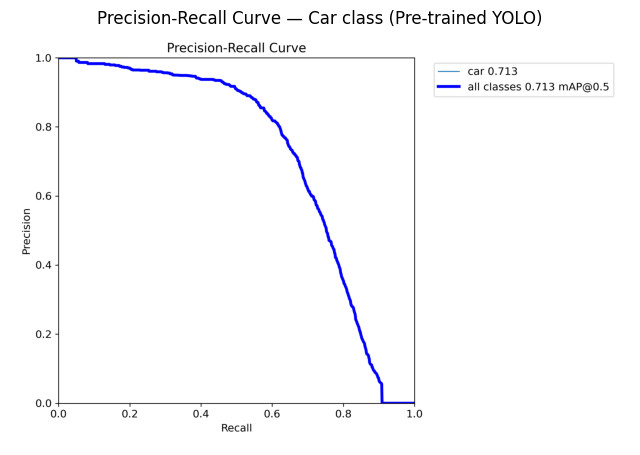

['val_batch1_labels.jpg', 'val_batch0_labels.jpg', 'BoxF1_curve.png', 'val_batch0_pred.jpg', 'val_batch2_labels.jpg', 'val_batch2_pred.jpg', 'BoxR_curve.png', 'val_batch1_pred.jpg', 'BoxPR_curve.png', 'confusion_matrix.png', 'BoxP_curve.png', 'confusion_matrix_normalized.png']


In [ ]:
# load pre-trained model
pretrained_model = YOLO('yolo11n.pt')

# dataset yaml path
dataset_yaml = '/content/kitti3k_yolo/kitti3k.yaml'

# evaluate on test set for Car class only (class index 2)
pretrained_val_metrics = pretrained_model.val(
    data=dataset_yaml,
    split='test',
    classes=[2],
    imgsz=640,
    conf=0.001,
    iou=0.7,
    exist_ok=True
)

print('Pre-trained YOLO — Car class evaluation on test set:')
print(f'AP50:    {pretrained_val_metrics.box.ap50[0]:.3f}')
print(f'AP50-95: {pretrained_val_metrics.box.ap[0]:.3f}')

## show curve
img = mpimg.imread('/content/runs/detect/val/BoxPR_curve.png')
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Precision-Recall Curve — Car class (Pre-trained YOLO)')
plt.show()

import os
print(os.listdir('/content/runs/detect/val'))